# 🎮 1D Playground: Diffusion & Flow Matching Sanity Checks

This notebook provides interactive 1D experiments to build intuition for diffusion models and flow matching.

**Why 1D?**
- Ultra-fast training (in seconds & CPU friendly)
- Easy to visualize distributions and flows
- Perfect for debugging and understanding

**Note:** You should be able to use this notebook with CPU only machines.

If you are using VSCode and you do not see your venv in the kernel options, first activate your venv in your terminal and run 

'''

uv run --active python -m ipykernel install --user --name cmu-10799 --display-name "Python (cmu-10799)"

'''

In VS Code:
- Command Palette → Python: Select Interpreter → pick .venv-(your env)/bin/python
- In the notebook → Select Kernel → pick .venv-(your env) or Python (cmu-10799-cpu)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

plt.style.use('default')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Create 1D Mixture of Gaussians

In [2]:
def get_1d_data(name, n_samples=10000):
    """Generate 1D mixture of Gaussians datasets with different weights."""
    if name == '2gaussians':
        # Two Gaussians at -2 and 2 (equal weights)
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.5, 0.5]
    elif name == '3gaussians':
        # Three Gaussians at -2, 0, 2 (equal weights)
        centers = [-2.0, 0.0, 2.0]
        std = 0.3
        weights = [1/3, 1/3, 1/3]
    elif name == '5gaussians':
        # Five evenly spaced Gaussians (equal weights)
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.2, 0.2, 0.2, 0.2, 0.2]
    elif name == 'uneven':
        # Uneven mixture with different spacing (equal weights)
        centers = [-3.5, -1.0, 0.5, 2.5]
        std = 0.3
        weights = [0.25, 0.25, 0.25, 0.25]
    elif name == 'wide':
        # Wider Gaussians (equal weights)
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.5, 0.5]
    elif name == 'weighted2':
        # Two Gaussians with different weights (tall left, short right)
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.8, 0.2]
    elif name == 'weighted3':
        # Three Gaussians with different weights (tall-short-medium)
        centers = [-2.5, 0.0, 2.5]
        std = 0.3
        weights = [0.5, 0.2, 0.3]
    elif name == 'weighted5':
        # Five Gaussians with varied weights
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.1, 0.15, 0.4, 0.25, 0.1]
    elif name == 'weighted_wide':
        # Wider Gaussians (unequal weights)
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.65, 0.35]
    else:
        raise ValueError(f"Unknown dataset: {name}")
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Sample from each Gaussian according to weights
    X = []
    for center, weight in zip(centers, weights):
        n_samples_for_center = int(n_samples * weight)
        samples = np.random.randn(n_samples_for_center, 1) * std + center
        X.append(samples)
    X = np.concatenate(X, axis=0)
    
    # Shuffle
    np.random.shuffle(X)
    
    return torch.tensor(X, dtype=torch.float32)


def get_ground_truth_density(name, x_values):
    """Compute the ground truth density for a given dataset at x_values."""
    if name == '2gaussians':
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.5, 0.5]
    elif name == '3gaussians':
        centers = [-2.0, 0.0, 2.0]
        std = 0.3
        weights = [1/3, 1/3, 1/3]
    elif name == '5gaussians':
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.2, 0.2, 0.2, 0.2, 0.2]
    elif name == 'uneven':
        centers = [-3.5, -1.0, 0.5, 2.5]
        std = 0.3
        weights = [0.25, 0.25, 0.25, 0.25]
    elif name == 'wide':
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.5, 0.5]
    elif name == 'weighted2':
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.8, 0.2]
    elif name == 'weighted3':
        centers = [-2.5, 0.0, 2.5]
        std = 0.3
        weights = [0.5, 0.2, 0.3]
    elif name == 'weighted5':
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.1, 0.15, 0.4, 0.25, 0.1]
    elif name == 'weighted_wide':
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.65, 0.35]
    else:
        raise ValueError(f"Unknown dataset: {name}")
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Compute mixture of Gaussians density
    density = np.zeros_like(x_values)
    for center, weight in zip(centers, weights):
        density += weight * (1.0 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_values - center) / std) ** 2)
    
    return density

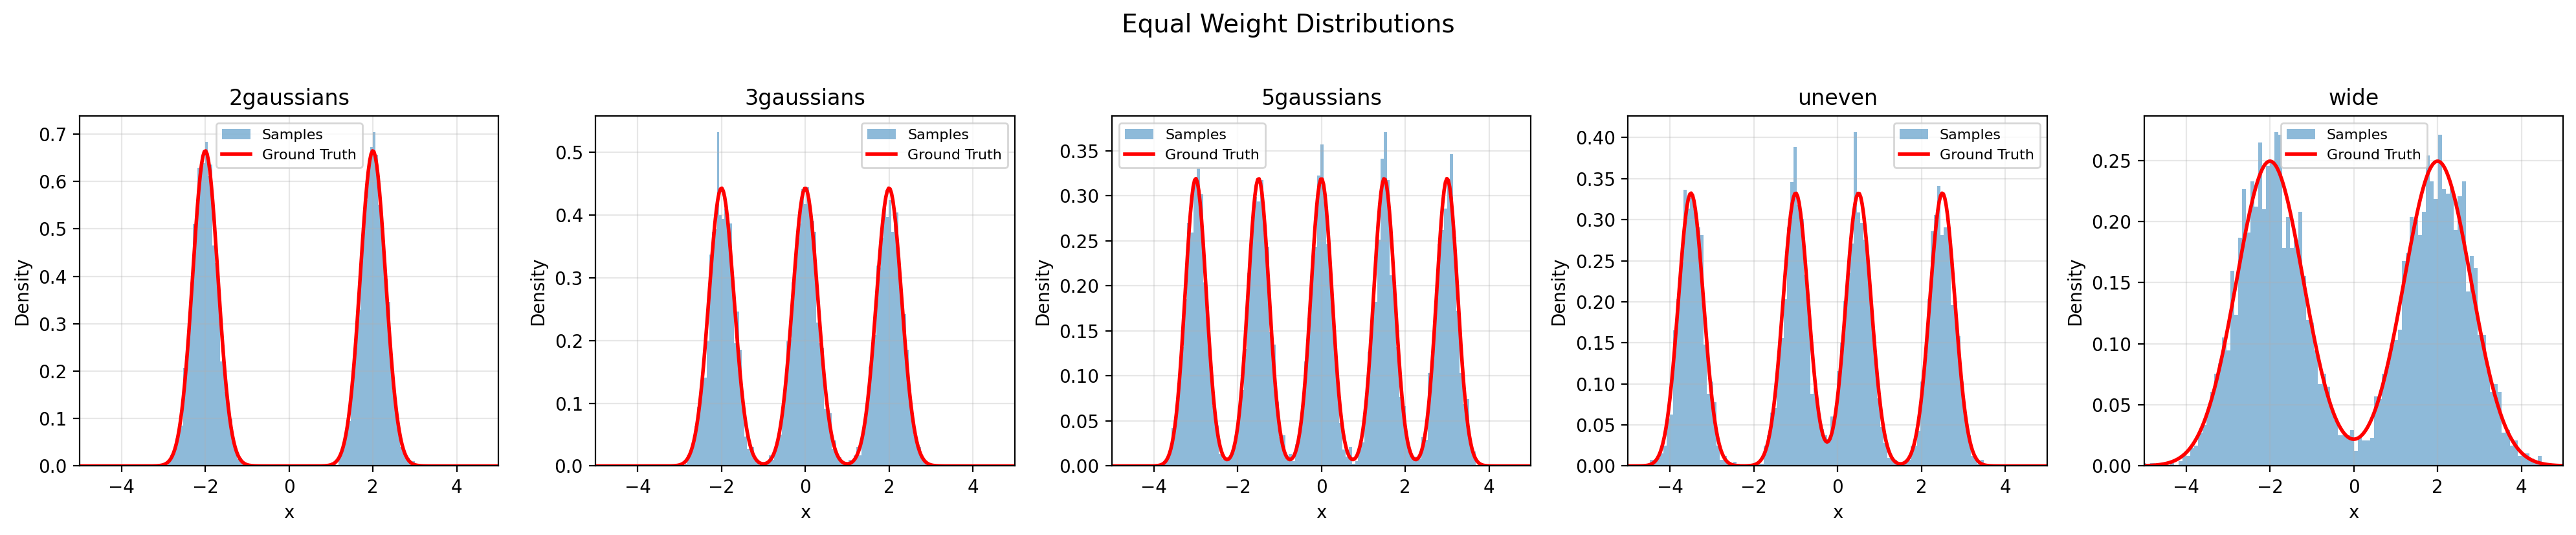

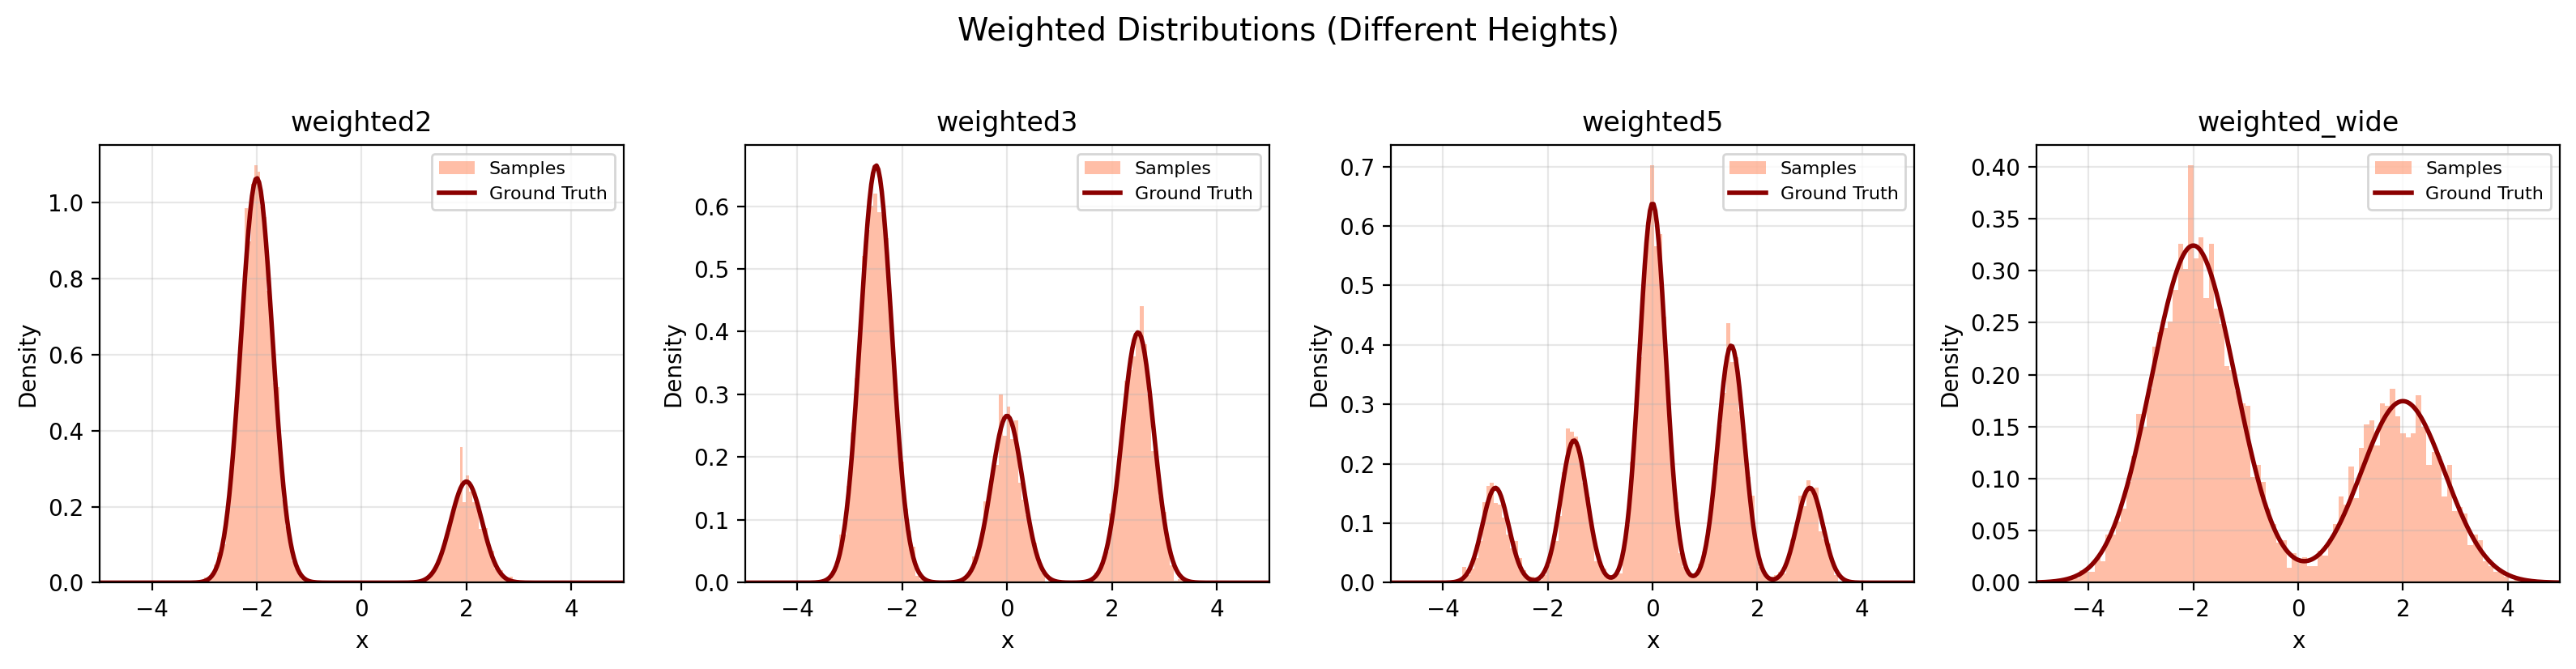

In [3]:
# Visualize available distributions
datasets_equal = ['2gaussians', '3gaussians', '5gaussians', 'uneven', 'wide']
datasets_weighted = ['weighted2', 'weighted3', 'weighted5', 'weighted_wide']

# Plot equal weight distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Equal Weight Distributions', fontsize=14, y=1.02)
for ax, name in zip(axes, datasets_equal):
    data = get_1d_data(name, n_samples=5000)
    ax.hist(data.numpy(), bins=100, density=True, alpha=0.5, label='Samples')
    
    # Overlay ground truth
    x_line = np.linspace(-5, 5, 300)
    density = get_ground_truth_density(name, x_line)
    ax.plot(x_line, density, 'r-', linewidth=2, label='Ground Truth')
    
    ax.set_title(name)
    ax.set_xlim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plot weighted distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Weighted Distributions (Different Heights)', fontsize=14, y=1.02)
for ax, name in zip(axes, datasets_weighted):
    data = get_1d_data(name, n_samples=5000)
    ax.hist(data.numpy(), bins=100, density=True, alpha=0.5, color='coral', label='Samples')
    
    # Overlay ground truth
    x_line = np.linspace(-5, 5, 300)
    density = get_ground_truth_density(name, x_line)
    ax.plot(x_line, density, 'darkred', linewidth=2, label='Ground Truth')
    
    ax.set_title(name)
    ax.set_xlim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Simple network for 1D

First design a simple network (like an MLP) to model the 1D data, remember to also include the time embeddings.

In [4]:
import math

class SinusoidalEmbedding(nn.Module):
    """Sinusoidal positional embedding for timesteps."""
    def __init__(self, dim, max_period=10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, t):
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(self.max_period) * torch.arange(half_dim, device=t.device) / half_dim
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class NoisePredictor1D(nn.Module):
    """Simple MLP noise predictor for 1D DDPM.
    
    Takes x_t (B, 1) and integer timestep t (B,), returns predicted noise (B, 1).
    """
    def __init__(self, hidden_dim=128, time_embed_dim=64):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(time_embed_dim),
            nn.Linear(time_embed_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(1 + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, t):
        # x: (B, 1), t: (B,)
        t_emb = self.time_embed(t)       # (B, hidden_dim)
        h = torch.cat([x, t_emb], dim=-1) # (B, 1 + hidden_dim)
        return self.net(h)


# Quick test
net = NoisePredictor1D().to(device)
x_test = torch.randn(4, 1, device=device)
t_test = torch.randint(0, 100, (4,), device=device)
out = net(x_test, t_test)
print(f"Input: {x_test.shape}, Timestep: {t_test.shape} -> Output: {out.shape}")
num_params = sum(p.numel() for p in net.parameters())
print(f"Parameters: {num_params:,}")

Input: torch.Size([4, 1]), Timestep: torch.Size([4]) -> Output: torch.Size([4, 1])
Parameters: 74,625


## 3. DDPM algorithm implementation

Implement the forward process, backward process, loss calculation and the sampling process of the DDPM algorithm. You can feel free to follow the structure of src/methods/ddpm.py or directly import your implementation from there.

In [5]:
class DDPM1D:
    """DDPM for 1D data. Follows the same structure as src/methods/ddpm.py
    but adapted for 1D tensors of shape (B, 1) instead of (B, C, H, W)."""

    def __init__(self, model, num_timesteps=100, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.model = model
        self.num_timesteps = num_timesteps
        self.device = device

        # Compute noise schedule
        self.beta_t = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alpha_t = 1.0 - self.beta_t
        self.alpha_bar_t = torch.cumprod(self.alpha_t, dim=0)
        self.sqrt_alpha_t = torch.sqrt(self.alpha_t)
        self.sqrt_alpha_bar_t = torch.sqrt(self.alpha_bar_t)
        self.sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - self.alpha_bar_t)
        self.sqrt_beta_t = torch.sqrt(self.beta_t)

    def forward_process(self, x_0, t, epsilon):
        """q(x_t | x_0) = N(sqrt(alpha_bar_t) * x_0, (1 - alpha_bar_t) * I)"""
        sqrt_alpha_bar = self.sqrt_alpha_bar_t[t].unsqueeze(-1)           # (B, 1)
        sqrt_one_minus = self.sqrt_one_minus_alpha_bar_t[t].unsqueeze(-1) # (B, 1)
        return sqrt_alpha_bar * x_0 + sqrt_one_minus * epsilon

    def compute_loss(self, x_0):
        """Simple DDPM loss: E[||epsilon - epsilon_theta(x_t, t)||^2]"""
        batch_size = x_0.shape[0]
        t = torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)
        epsilon = torch.randn_like(x_0)
        x_t = self.forward_process(x_0, t, epsilon)
        epsilon_pred = self.model(x_t, t)
        return F.mse_loss(epsilon_pred, epsilon)

    @torch.no_grad()
    def reverse_step(self, x_t, t):
        """One step of the reverse process: p(x_{t-1} | x_t)"""
        epsilon_pred = self.model(x_t, t)

        sqrt_alpha = self.sqrt_alpha_t[t].unsqueeze(-1)
        beta = self.beta_t[t].unsqueeze(-1)
        sqrt_one_minus = self.sqrt_one_minus_alpha_bar_t[t].unsqueeze(-1)
        sqrt_beta = self.sqrt_beta_t[t].unsqueeze(-1)

        # Predicted mean
        mean = (1.0 / sqrt_alpha) * (x_t - (beta / sqrt_one_minus) * epsilon_pred)

        # Add noise (except at t=0)
        z = torch.randn_like(x_t) * (t != 0).float().unsqueeze(-1)
        return mean + sqrt_beta * z

    @torch.no_grad()
    def sample(self, n_samples, return_trajectory=False):
        """Sample by running the full reverse process from t=T to t=0."""
        self.model.eval()
        x_t = torch.randn(n_samples, 1, device=self.device)
        trajectory = [x_t.cpu()] if return_trajectory else None

        for timestep in range(self.num_timesteps - 1, -1, -1):
            t = torch.full((n_samples,), timestep, device=self.device, dtype=torch.long)
            x_t = self.reverse_step(x_t, t)
            if return_trajectory:
                trajectory.append(x_t.cpu())

        self.model.train()
        if return_trajectory:
            return x_t, trajectory
        return x_t

print("DDPM1D ready.")

DDPM1D ready.


## 4. Training

Write your training loop here (or you can combine it above, whichever way is easier for you)

Training on 2gaussians:   0%|          | 0/1000 [00:00<?, ?it/s]

Training on 3gaussians:   0%|          | 0/1000 [00:00<?, ?it/s]

Training on weighted3:   0%|          | 0/1000 [00:00<?, ?it/s]

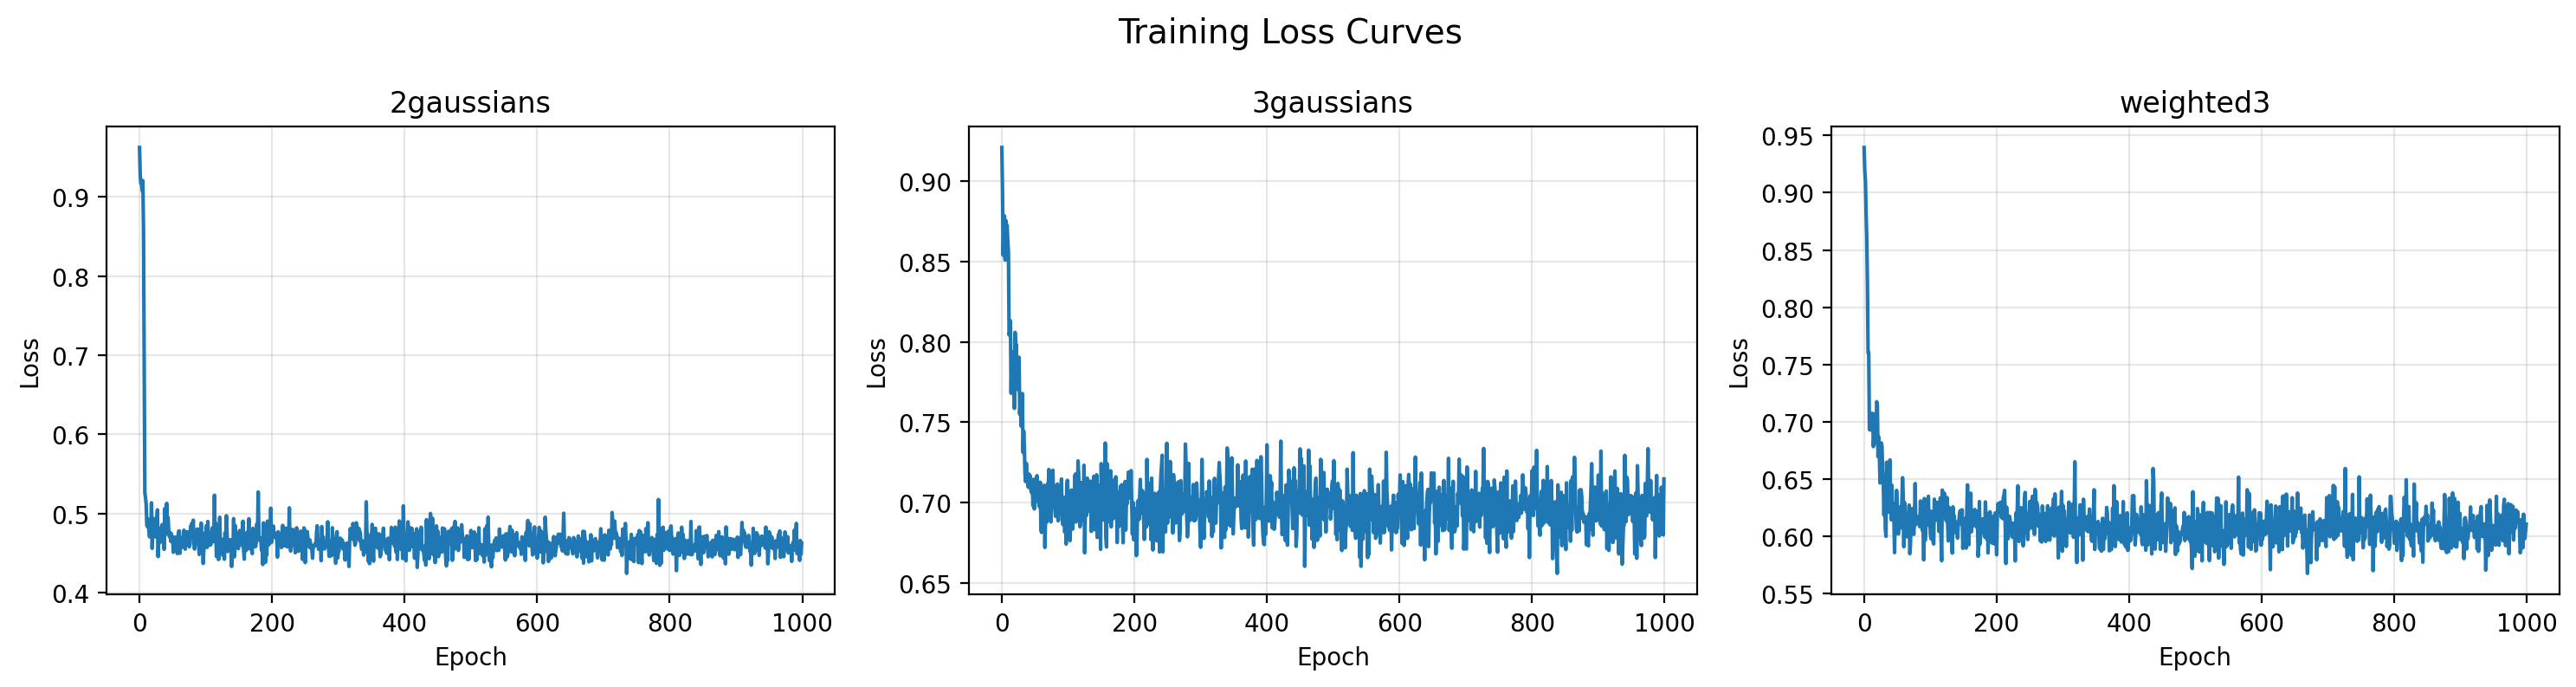

In [6]:
def train_ddpm_1d(dataset_name, n_epochs=1000, num_timesteps=100, lr=1e-3, batch_size=256):
    """Train a 1D DDPM on the given dataset."""
    data = get_1d_data(dataset_name, n_samples=10000).to(device)

    model = NoisePredictor1D(hidden_dim=128, time_embed_dim=64).to(device)
    ddpm = DDPM1D(model, num_timesteps=num_timesteps, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in tqdm(range(n_epochs), desc=f"Training on {dataset_name}"):
        perm = torch.randperm(data.shape[0])
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, data.shape[0], batch_size):
            batch = data[perm[i:i + batch_size]]
            loss = ddpm.compute_loss(batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)

    return ddpm, losses


# Train on a few distributions
datasets_to_train = ['2gaussians', '3gaussians', 'weighted3']
trained_models = {}

for name in datasets_to_train:
    ddpm, losses = train_ddpm_1d(name, n_epochs=1000)
    trained_models[name] = (ddpm, losses)

# Plot training curves
fig, axes = plt.subplots(1, len(datasets_to_train), figsize=(5 * len(datasets_to_train), 4))
for ax, name in zip(axes, datasets_to_train):
    ax.plot(trained_models[name][1])
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
plt.suptitle('Training Loss Curves', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Visualize Samples

Visualize your learned distributions and compare them with the ground truth. I have left my visualization results for you as reference.

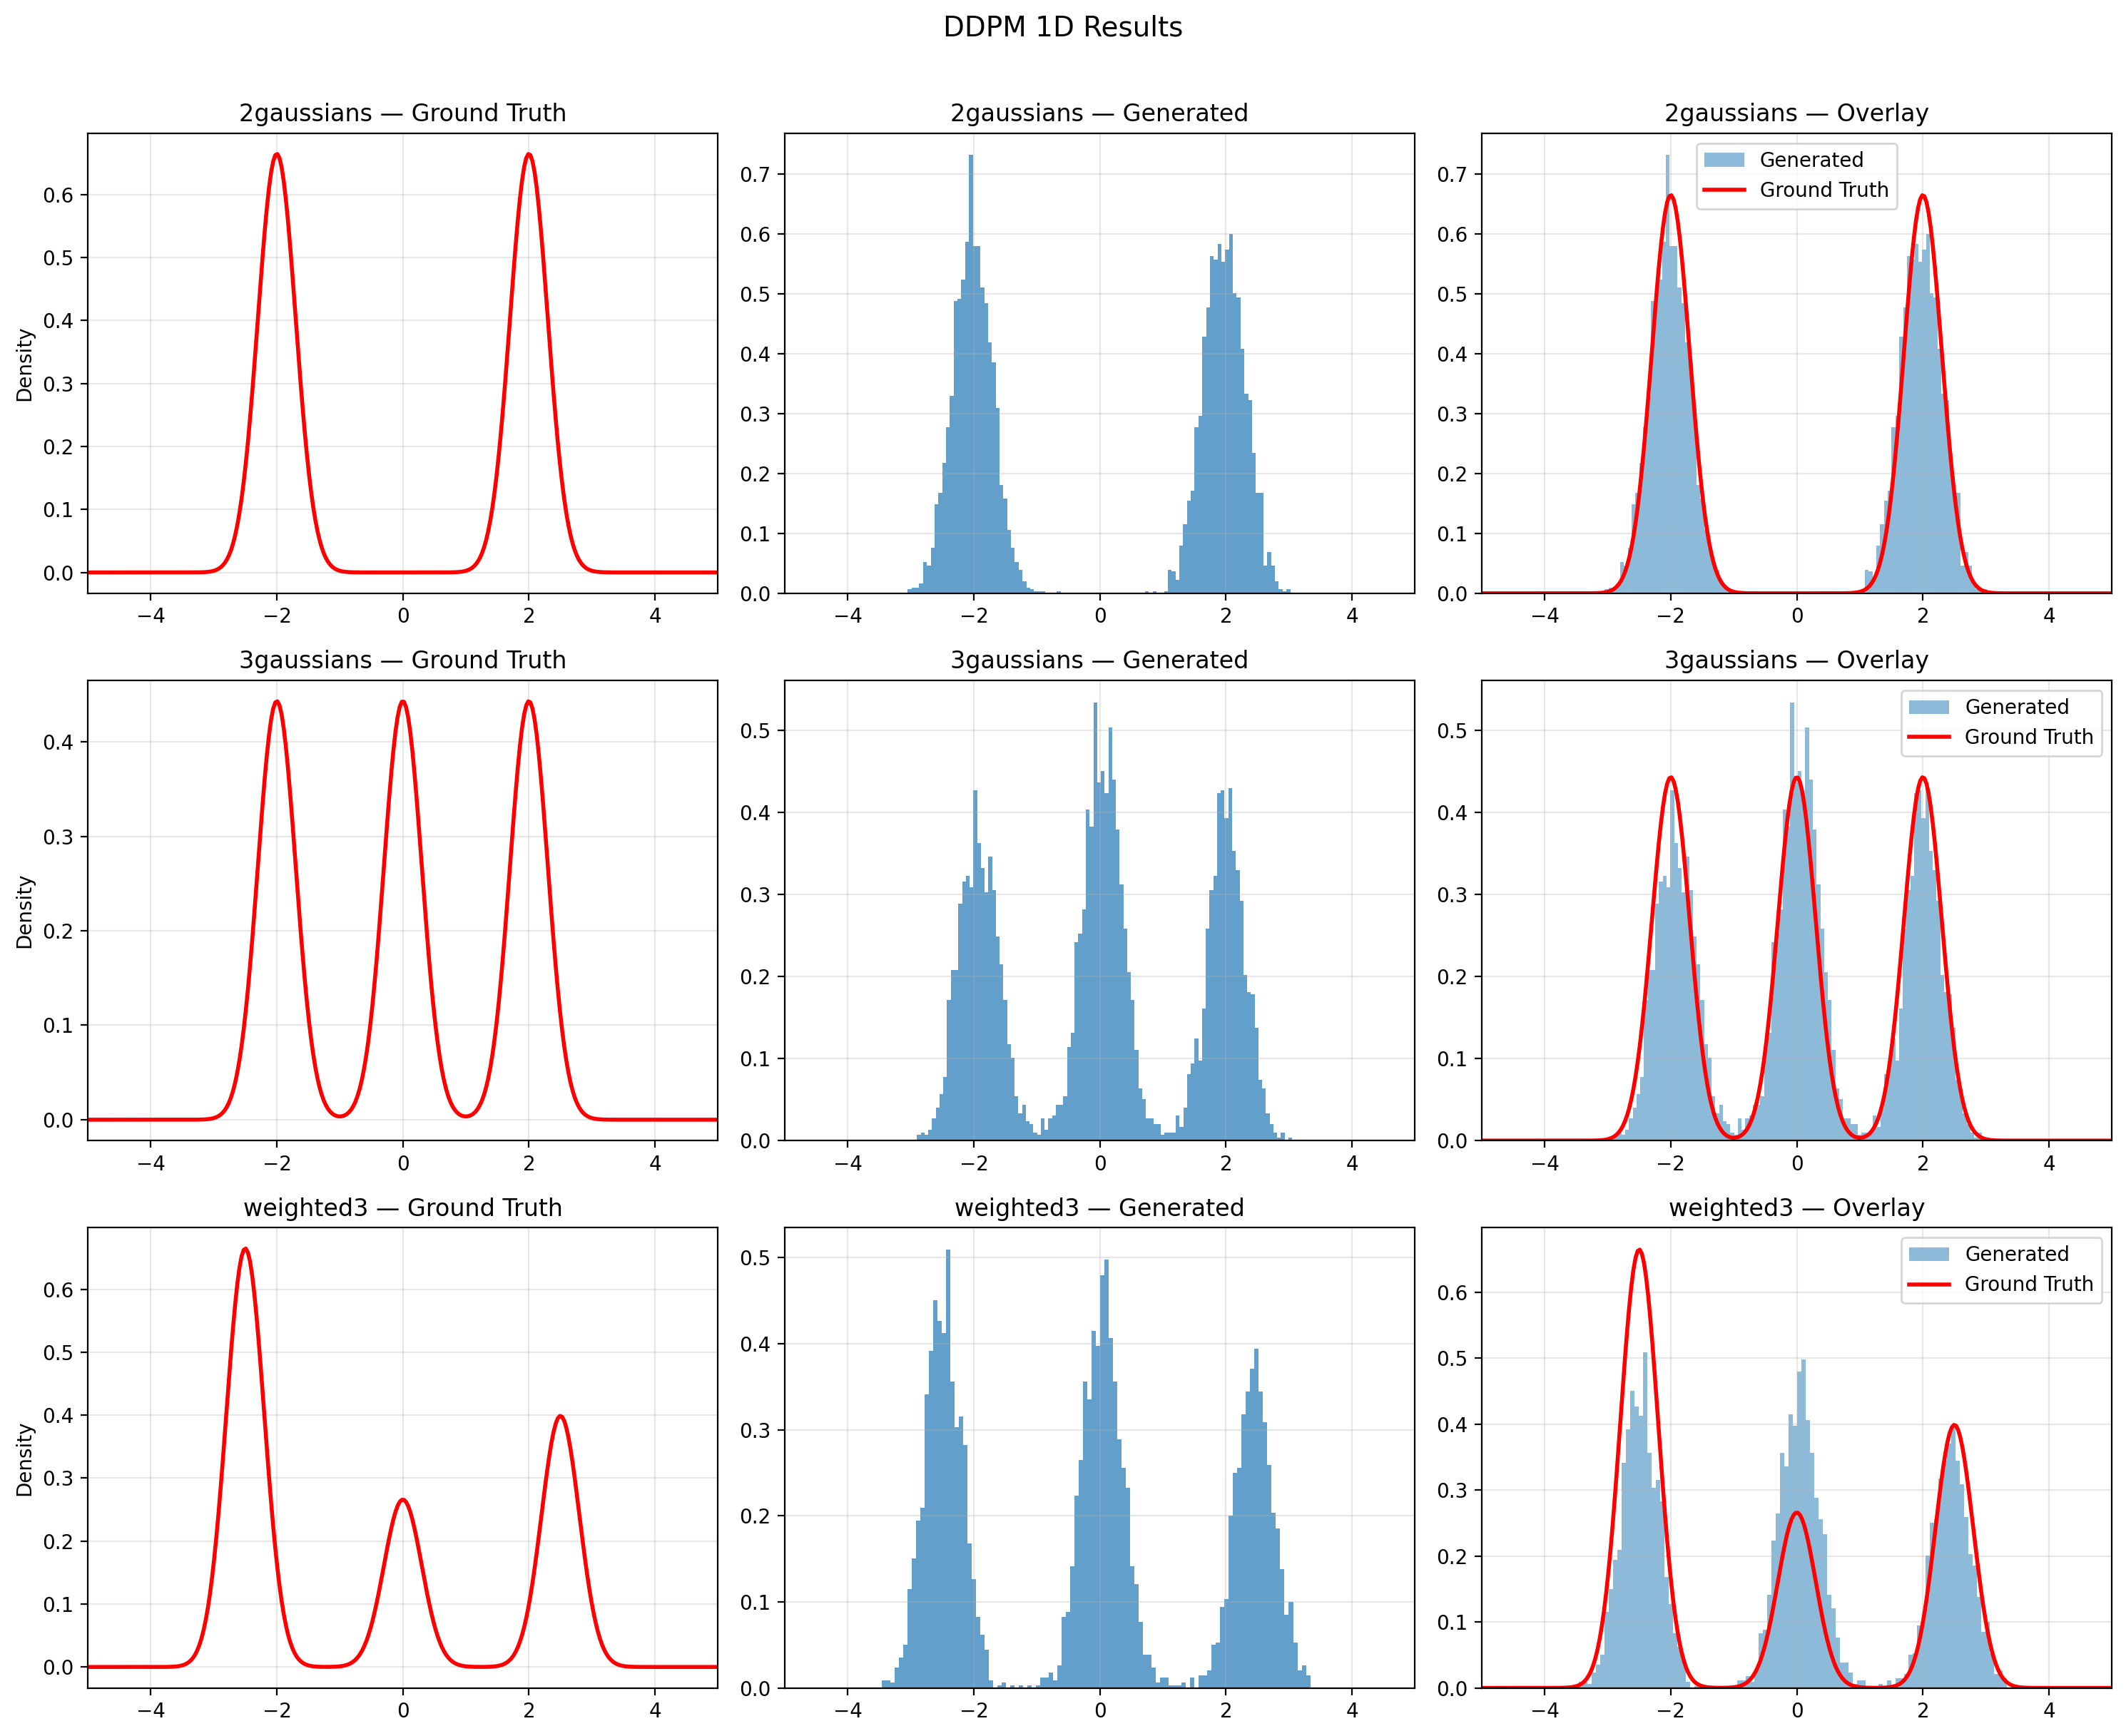

In [7]:
n_samples = 5000

fig, axes = plt.subplots(len(datasets_to_train), 3, figsize=(15, 4 * len(datasets_to_train)))

for row, name in enumerate(datasets_to_train):
    ddpm = trained_models[name][0]
    samples = ddpm.sample(n_samples).cpu().numpy()

    x_line = np.linspace(-5, 5, 300)
    gt_density = get_ground_truth_density(name, x_line)

    # Ground truth
    axes[row, 0].plot(x_line, gt_density, 'r-', linewidth=2)
    axes[row, 0].set_title(f'{name} — Ground Truth')
    axes[row, 0].set_xlim(-5, 5)
    axes[row, 0].set_ylabel('Density')
    axes[row, 0].grid(True, alpha=0.3)

    # Generated samples
    axes[row, 1].hist(samples, bins=100, density=True, alpha=0.7)
    axes[row, 1].set_title(f'{name} — Generated')
    axes[row, 1].set_xlim(-5, 5)
    axes[row, 1].grid(True, alpha=0.3)

    # Overlay
    axes[row, 2].hist(samples, bins=100, density=True, alpha=0.5, label='Generated')
    axes[row, 2].plot(x_line, gt_density, 'r-', linewidth=2, label='Ground Truth')
    axes[row, 2].set_title(f'{name} — Overlay')
    axes[row, 2].set_xlim(-5, 5)
    axes[row, 2].legend()
    axes[row, 2].grid(True, alpha=0.3)

plt.suptitle('DDPM 1D Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Visualize Sampling Trajectories

Besides visualizing the final results, you can also visualize the entire sampling trajectory in order to get a better understanding of the process. Here I also left you my visualization results as an example.

In [8]:
def plot_trajectory(trajectory, title, n_points=1000, n_steps_show=10, dataset_name=None):
    """Plot sampling trajectory."""
    n_total_steps = len(trajectory)
    step_indices = np.linspace(0, n_total_steps-1, n_steps_show, dtype=int)
    
    fig, axes = plt.subplots(1, n_steps_show, figsize=(2*n_steps_show, 3))
    
    # Prepare ground truth for final step if dataset name provided
    if dataset_name is not None:
        x_line = np.linspace(-5, 5, 300)
        gt_density = get_ground_truth_density(dataset_name, x_line)
    
    for ax, step_idx in zip(axes, step_indices):
        points = trajectory[step_idx][:n_points]
        ax.hist(points.numpy(), bins=50, density=True, alpha=0.7)
        
        # Overlay ground truth on final step
        if dataset_name is not None and step_idx == step_indices[-1]:
            ax.plot(x_line, gt_density, 'r-', linewidth=2, alpha=0.8)
        
        ax.set_xlim(-5, 5)
        ax.set_ylim(0, 1.2)
        ax.set_title(f't={step_idx}', fontsize=10)
        ax.set_xlabel('x', fontsize=8)
        if ax == axes[0]:
            ax.set_ylabel('Density', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

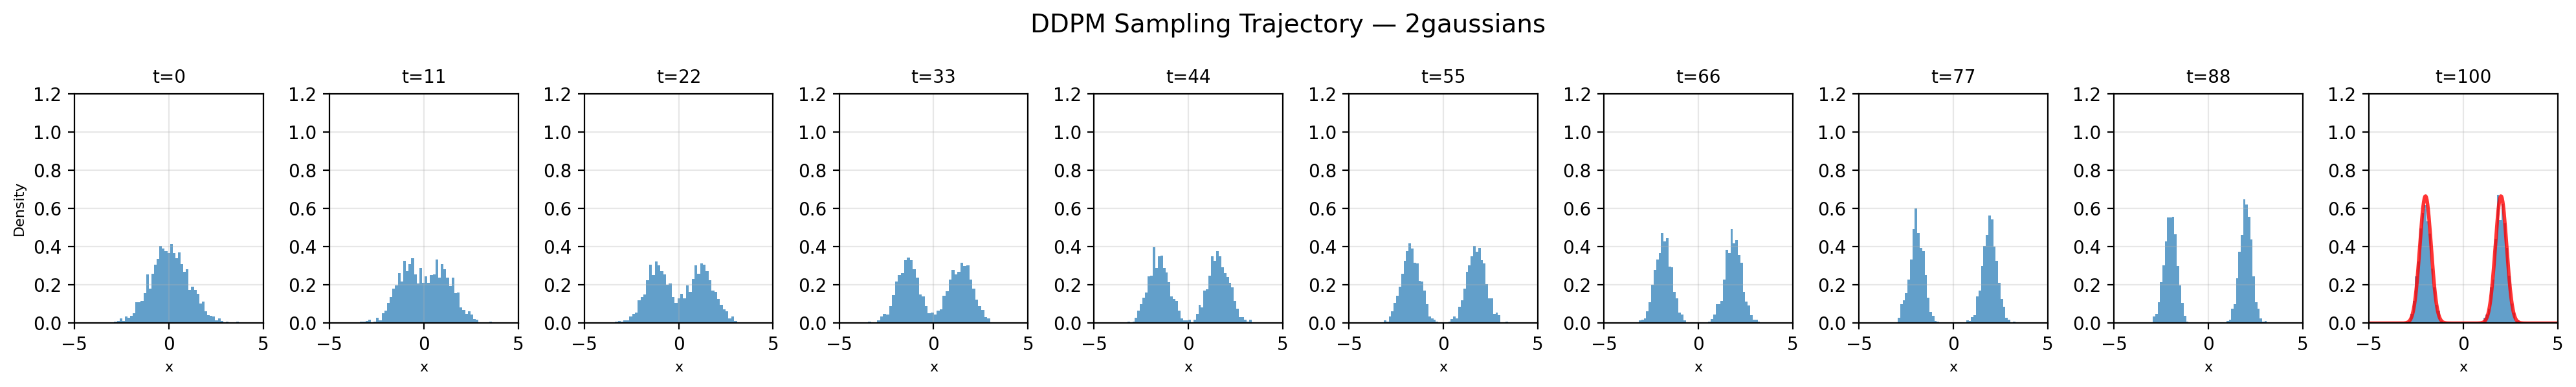

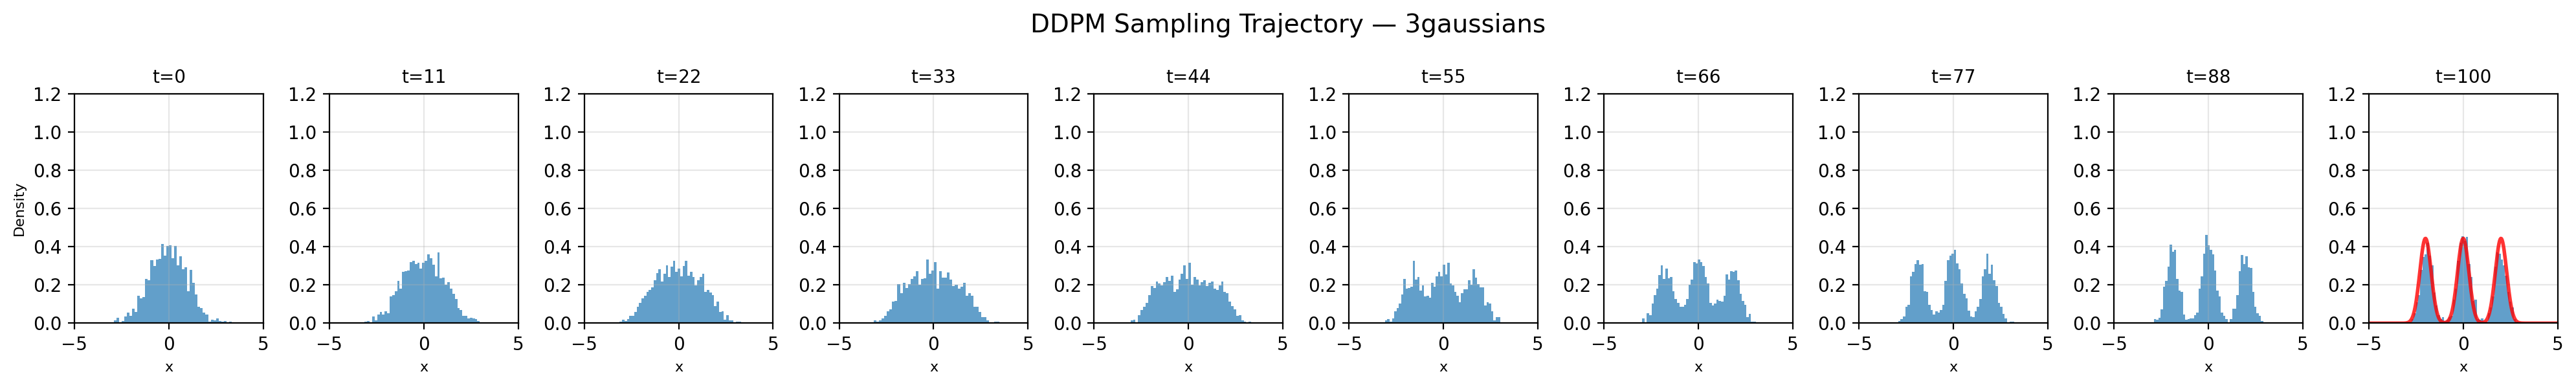

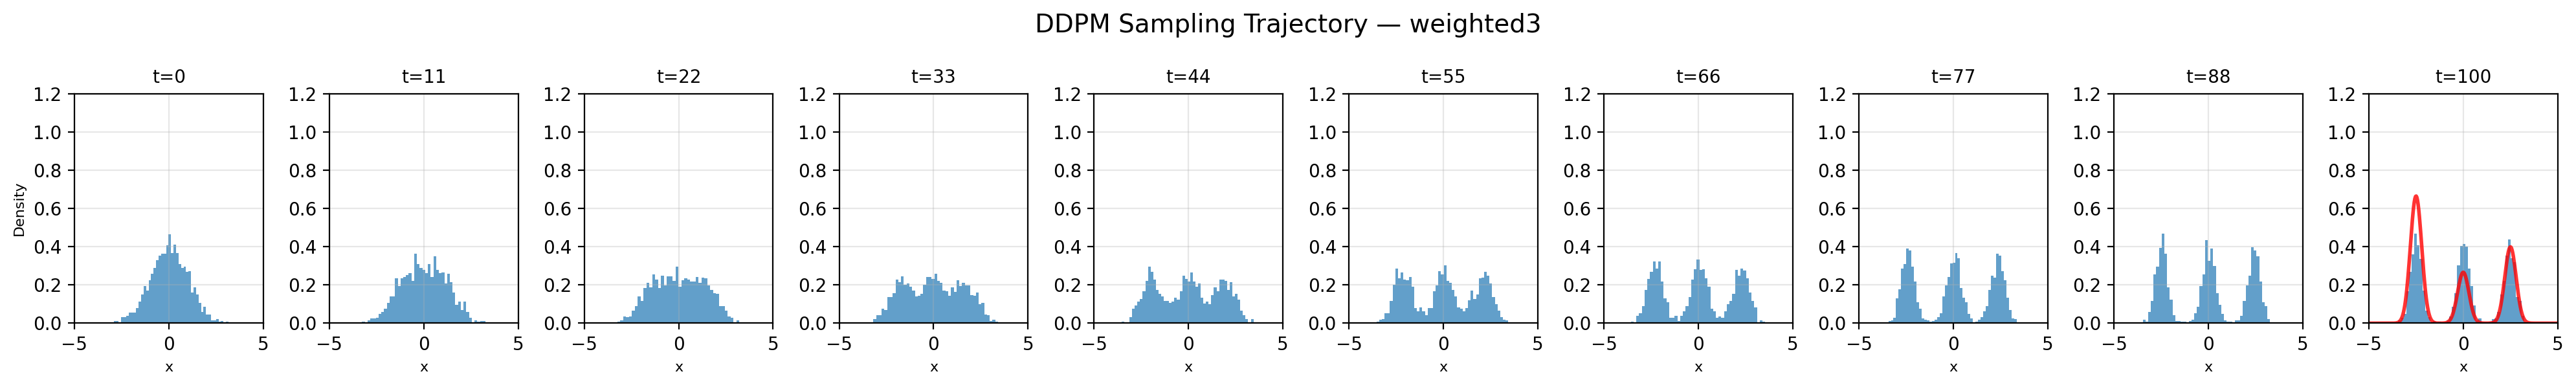

In [9]:
# Generate and visualize sampling trajectories
for name in datasets_to_train:
    ddpm = trained_models[name][0]
    _, trajectory = ddpm.sample(2000, return_trajectory=True)
    plot_trajectory(
        trajectory,
        f'DDPM Sampling Trajectory — {name}',
        n_points=2000,
        n_steps_show=10,
        dataset_name=name,
    )